In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

In [2]:
# Prep dataset

df = pd.read_csv("stroke_data.csv")

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,32235,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,NaN,smokes,0
1,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
3,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
4,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1


### Question 1: Outliers Removal and Transformation

In [3]:
# Kurtosis and Skewness values of avg glucose level?

# skewness = measures the asymmetry of a distribution around its mean.
# ~ 0 == roughlu symmetric
# > 0 == tail is longer on the right, more high extreme values
# < 0 == tail is longer on the left, more low extreme values

# Kurtosis = measures the outliers, how heavy or light the tails are compared to a normal distribution
# Normal = 0
# > 0 == heavier tails, more outliers
# < 0 == lighter tails, fewer outliers


kurt = kurtosis(df['avg_glucose_level'], nan_policy='omit')     # nan_policy='omit' == ignores the missing values
skw = skew(df['avg_glucose_level'], nan_policy='omit')
print("Kurtosis:", kurt)
print("Skewness:", skw)

Kurtosis: 1.6832979725142145
Skewness: 1.573103476107217


The results

- skewness = its positive, therefore it is showing that most patient's values are on the lower side, but there are a number of patients with very higgh glucose levels. Many people have normal or slightly elevated glucose, but a few cases of diabetes cause very high readings.
- kurtosis = the distribution is leptokurtic, therefore, it has heavier tails and more outliers than a normal curve. There are more extreme glucose values in the dataset.

In [4]:
# Filter rows where bmi is missing 

df = df[df['bmi'].notna()].copy()
print("Filtered dataframe shape:", df.shape)

Filtered dataframe shape: (4915, 12)


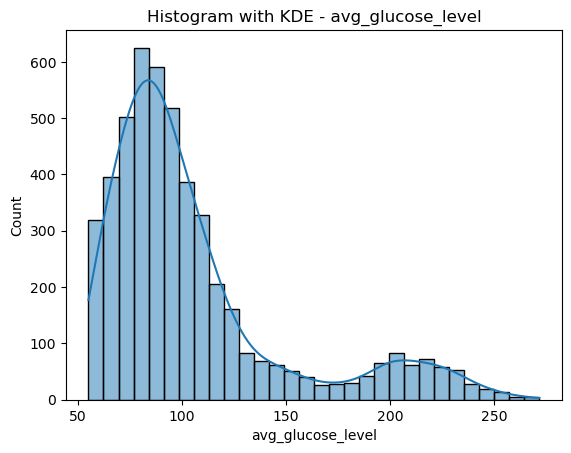

In [5]:
# Histogram of avg glucose level

sns.histplot(df['avg_glucose_level'], kde=True, bins=30)
plt.title("Histogram with KDE - avg_glucose_level")
plt.show()


The result of the histogram
- This histogram is showing that potentially there are just few outliers. The average glucose level is around the standard for majority of people in the dataset. There are just few data representing the higher glucose level.

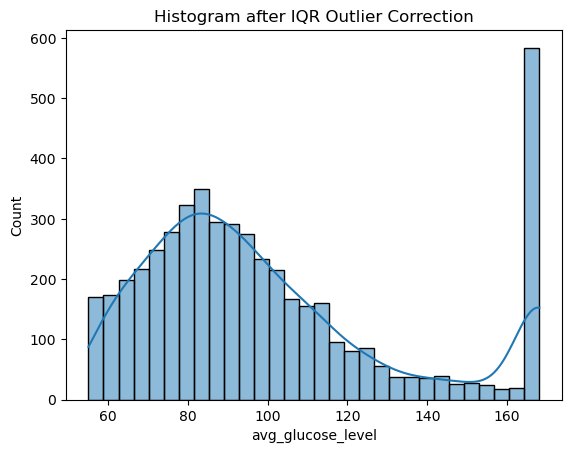

In [6]:
# Identify the outliers using IQR

Q1 = df['avg_glucose_level'].quantile(0.25)
Q3 = df['avg_glucose_level'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Impute outliers
df['avg_glucose_level'] = np.where(df['avg_glucose_level'] > upper, upper,
                          np.where(df['avg_glucose_level'] < lower, lower, df['avg_glucose_level']))

# Histogram plot
sns.histplot(df['avg_glucose_level'], kde=True, bins=30)
plt.title("Histogram after IQR Outlier Correction")
plt.show()


The results
- After the calculation, any value outside of the range of Q1 and Q3, it was set to 165. If the glucose level was more than 165, it was set to 165.
- The histogram is looking more clearer now. 
    - Mainly there are patients with avg glucose level 60-120, which is normal range with the peak 80-90.
    - There is the gradual decline between 120-160, which is still normal for a human being to experience higher glucose level.
    - The suddent spike at 165, this is all the values that were after 165. We can see that these are the outliers, and there is many of them.

- Before the outliers detection, the extreme high glucose values were pulling the mean upwards and streatching the tail. However, after the correction, the tail is reduced and no values above 165 exist anymore.

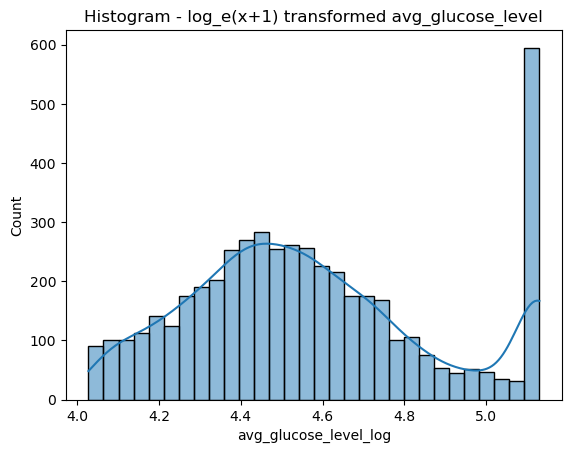

In [7]:
# Using log function make the glucose values have a normal distribution

df['avg_glucose_level_log'] = np.log(df['avg_glucose_level'] + 1)
sns.histplot(df['avg_glucose_level_log'], kde=True, bins=30)
plt.title("Histogram - log_e(x+1) transformed avg_glucose_level")
plt.show()

In [8]:
# Kurtosis and Skewness after transformation 

kurt_t = kurtosis(df['avg_glucose_level_log'], nan_policy='omit')
skw_t = skew(df['avg_glucose_level_log'], nan_policy='omit')
print("Kurtosis (after):", kurt_t)
print("Skewness (after):", skw_t)

Kurtosis (after): -0.6197874411011228
Skewness (after): 0.43791421862913443


The results
- Skewness = it is getting closer to 0, which means that the data is almost symmetric.
- Kurtosis = it is negative, therefore it has light tails, and there are fewer outliers

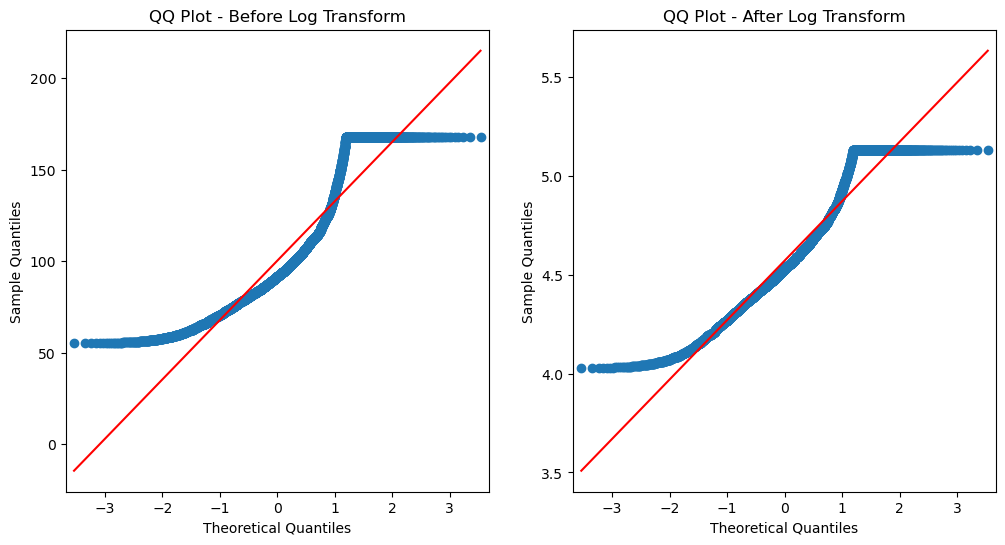

In [9]:
# 2 plots to compare before and after transformation

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sm.qqplot(df['avg_glucose_level'], line='s', ax=axes[0])
axes[0].set_title("QQ Plot - Before Log Transform")

sm.qqplot(df['avg_glucose_level_log'], line='s', ax=axes[1])
axes[1].set_title("QQ Plot - After Log Transform")

plt.show()

In [11]:
# Detection and correction of bmi and age

def correct_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return np.where(series > upper, upper,
           np.where(series < lower, lower, series))

df['bmi'] = correct_outliers(df['bmi'])
df['age'] = correct_outliers(df['age'])

print(df['bmi'])
print(df['age'])


1       36.6
3       32.5
4       34.4
5       24.0
6       29.0
        ... 
5112    40.0
5113    30.6
5114    25.6
5115    26.2
5116    28.3
Name: bmi, Length: 4915, dtype: float64
1       67.0
3       80.0
4       49.0
5       79.0
6       81.0
        ... 
5112    81.0
5113    35.0
5114    51.0
5115    44.0
5116    69.0
Name: age, Length: 4915, dtype: float64


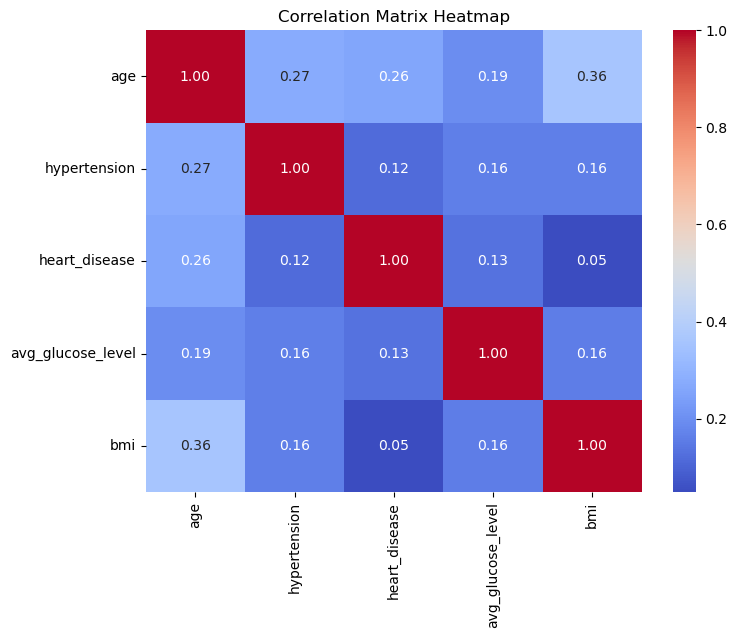

In [12]:
# Correlation matrix between continous variables

plt.figure(figsize=(8,6))
sns.heatmap(df[['age','hypertension','heart_disease','avg_glucose_level','bmi']].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()


The correlation matrix

Values ranges:
- +1 == when one increases, the other always increases
- 0 == no correlation
- -1 == when one increases, the other always decreases

Colors:
- red = stronger positive correlation
- blue = weak correlation

Results
- Bmi vs Age = this is the highest correlation in the table, meaning that if age increases the bmi increases as well
- Age vs Hypertension = older people are moer likely to have hypertension
- Age vs Heart Disease = again older patients have slightly higher glucose on average
- Hypertension vs Heart Disease = very weak, but still positive. Therefore having hypertension is a little linked with heart diseases.
- Bmi vs Heart Disease = thats almost on 0, basically no relationship. Bmi doesnt tell much about the heart disease in this dataset

### Question 2: Data Processing

In [13]:
# Group patients by work type and avg bmi

df.groupby('work_type')['bmi'].mean()


work_type
Govt_job         30.400159
Never_worked     25.545455
Private          30.090409
Self-employed    30.094981
children         20.038003
Name: bmi, dtype: float64

In [14]:
# Group patients by smoking status and avg age, avg glucose level, count of stroke cases

df.groupby('smoking_status').agg(
    avg_age=('age','mean'),
    avg_glucose=('avg_glucose_level','mean'),
    stroke_count=('stroke','sum')
)


,avg_age,avg_glucose,stroke_count
smoking_status,,,
Unknown,29.508156,96.111820,29
formerly smoked,54.957092,104.453689,57
never smoked,46.469222,101.480049,84
smokes,47.008130,100.902256,39


In [15]:
# Add new column glucose bmi ration with the values avg glucose level over bmi

df['glucose_bmi_ratio'] = df['avg_glucose_level'] / df['bmi']
df[['avg_glucose_level','bmi','glucose_bmi_ratio']].head()


,avg_glucose_level,bmi,glucose_bmi_ratio
1,168.075,36.6,4.592213
3,105.920,32.5,3.259077
4,168.075,34.4,4.885901
5,168.075,24.0,7.003125
6,168.075,29.0,5.795690


In [16]:
# Add a new column risk category

def risk_category(row):
    if row['age'] > 65 and (row['hypertension'] == 1 or row['heart_disease'] == 1):
        return 'Very High'
    elif row['age'] > 50 and row['avg_glucose_level'] > 200:
        return 'High'
    elif (40 < row['age'] <= 50) or (row['avg_glucose_level'] > 140):
        return 'Medium'
    else:
        return 'Low'

df['risk_category'] = df.apply(risk_category, axis=1)
df[['age','hypertension','heart_disease','avg_glucose_level','risk_category']].head()


,age,hypertension,heart_disease,avg_glucose_level,risk_category
1,67.0,0,1,168.075,Very High
3,80.0,0,1,105.920,Very High
4,49.0,0,0,168.075,Medium
5,79.0,1,0,168.075,Very High
6,81.0,0,0,168.075,Medium


In [17]:
# Merge 2 datasets by age

age_groups = pd.read_csv("age_groups.csv")

# round age to int before merging
df['age_int'] = df['age'].round().astype(int)

df = df.merge(age_groups, left_on='age_int', right_on='age', how='left', suffixes=('','_drop'))
df.drop(columns=['age_drop'], inplace=True)

df[['age','age_category']].head()


,age,age_category
0,67.0,Senior
1,80.0,Senior
2,49.0,Adult
3,79.0,Senior
4,81.0,Senior


In [18]:
# Encode the ategorical variables smoking status and work type, and add the results to the dataframe

df = pd.get_dummies(df, columns=['smoking_status','work_type'], drop_first=False)
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,...,age_category,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children
0,9046,Male,67.0,0,1,Yes,Urban,168.075,36.6,1,...,Senior,False,True,False,False,False,False,True,False,False
1,31112,Male,80.0,0,1,Yes,Rural,105.920,32.5,1,...,Senior,False,False,True,False,False,False,True,False,False
2,60182,Female,49.0,0,0,Yes,Urban,168.075,34.4,1,...,Adult,False,False,False,True,False,False,True,False,False
3,1665,Female,79.0,1,0,Yes,Rural,168.075,24.0,1,...,Senior,False,False,True,False,False,False,False,True,False
4,56669,Male,81.0,0,0,Yes,Urban,168.075,29.0,1,...,Senior,False,True,False,False,False,False,True,False,False


In [19]:
# Create new binary feature

df['is_elderly'] = (df['age'] >= 60).astype(int)
df[['age','is_elderly']].head()


,age,is_elderly
0,67.0,1
1,80.0,1
2,49.0,0
3,79.0,1
4,81.0,1


In [20]:
# Normalize the bmi and avg glucose level

scaler = StandardScaler()
df[['bmi_scaled','avg_glucose_scaled']] = scaler.fit_transform(df[['bmi','avg_glucose_level']])

# Save scaler
import joblib
joblib.dump(scaler, 'scaler.pkl')

df[['bmi','avg_glucose_level','bmi_scaled','avg_glucose_scaled']].head()


,bmi,avg_glucose_level,bmi_scaled,avg_glucose_scaled
0,36.6,168.075,1.072047,2.087704
1,32.5,105.920,0.512970,0.173740
2,34.4,168.075,0.772055,2.087704
3,24.0,168.075,-0.646093,2.087704
4,29.0,168.075,0.035709,2.087704
